In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import storage
import io

In [36]:
import google.auth
from google.auth import impersonated_credentials

credentials, project = google.auth.default()
print(credentials, project)

service_account = "le-wagon-bootcamp@le-wagon-2303.iam.gserviceaccount.com"
signing_credentials = impersonated_credentials.Credentials(
    source_credentials=credentials,
    target_principal=service_account,
    target_scopes=["https://www.googleapis.com/auth/cloud-platform"],
    lifetime=3600,
)

bucket_client = storage.Client(project='le-wagon-2303',  credentials=signing_credentials)
bucket = bucket_client.bucket('sm-optimizer-processed')

clean_blob = bucket.blob("posts_clean.csv")
df = pd.read_csv(clean_blob.open('rb'))
df.head()


<google.oauth2.service_account.Credentials object at 0xfffec85bfd70> wagon-ds-2026


,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,cost_nzd,views,hours,engagement
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,NaN,38409.0,64.3328,682.0
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,NaN,235384.0,544.8062,3800.0
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,NaN,274028.0,712.1043,3261.0
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",NaN,281319.0,623.9321,4929.0
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,NaN,438181.0,894.3045,9850.0


In [37]:
### existing descriptions JSONs
yt_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/youtube")
yt_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in yt_description_blobs]

tt_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/tiktok")
tt_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in tt_description_blobs]

fb_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/facebook")
fb_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in fb_description_blobs]

ig_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/instagram")
ig_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in ig_description_blobs]

all_description_keys = yt_description_keys + tt_description_keys + fb_description_keys + ig_description_keys
print(all_description_keys[12], all_description_keys[-40])
print('descriptions in bucket:', len([k for k in all_description_keys if k]))

-D1tJ_VPX9A 7503332873173339400
descriptions in bucket: 2853


In [38]:
print(df.columns)

Index(['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0',
       'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views',
       'hours', 'engagement'],
      dtype='object')


In [39]:
import json
import re
from concurrent.futures import ThreadPoolExecutor

PLATFORM_TO_PREFIX = {"YT": "yt", "TT": "tt", "FB": "fb", "IG": "ig"}
PLATFORM_TO_FOLDER = {"YT": "youtube", "TT": "tiktok", "FB": "facebook", "IG": "instagram"}
JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]
URL_ID_PATTERNS = {
    "FB": r"/(?:reel|video|videos|posts|share|v)/([\w-]+)",
    "YT": r"(?:v=|youtu\.be/|embed/)([\w-]{6,})",
    "TT": r"/video/(\d+)",
    "IG": r"/(?:p|reel|tv)/([\w-]+)",
}

def _url_id(url, platform):
    if pd.isna(url):
        return None
    match = re.search(URL_ID_PATTERNS[platform], str(url))
    return match.group(1) if match else None

platform_description_keys = {
    "YT": set(yt_description_keys),
    "TT": set(tt_description_keys),
    "FB": set(fb_description_keys),
    "IG": set(ig_description_keys),
}
key_to_blob = {
    (platform, url_id): f"gemini-descriptions/{PLATFORM_TO_FOLDER[platform]}/{url_id}.json"
    for platform, keys in platform_description_keys.items()
    for url_id in keys
}

platforms = df["platform"].tolist()
urls = df["url"].tolist()
url_ids = [_url_id(url, plat) for url, plat in zip(urls, platforms)]

valid_pairs = [
    (plat, uid) if plat in PLATFORM_TO_PREFIX and uid is not None and (plat, uid) in key_to_blob else None
    for plat, uid in zip(platforms, url_ids)
]
matched_pos = [i for i, p in enumerate(valid_pairs) if p is not None]
matched_indices = df.index[matched_pos]
blob_paths = [key_to_blob[valid_pairs[i]] for i in matched_pos]

def _fetch(blob_path):
    return json.loads(bucket.blob(blob_path).download_as_bytes())

with ThreadPoolExecutor(max_workers=16) as ex:
    json_by_idx_list = list(ex.map(_fetch, blob_paths))

json_by_idx = dict(zip(matched_indices, json_by_idx_list))

df["description"] = pd.Series(
    [(d.get("play_by_play") or "").strip() or pd.NA for d in json_by_idx_list],
    index=matched_indices, dtype="string",
).reindex(df.index)

vocabulary = {
    field: {
        value
        for d in json_by_idx_list
        for value in (d.get(field, []) or [])
    }
    for field in JSON_LIST_FIELDS
}

oh_data = {
    f"json_{field}_{value}": pd.Series(
        [int(value in (d.get(field, []) or [])) for d in json_by_idx_list],
        index=matched_indices, dtype="int8",
    )
    for field in JSON_LIST_FIELDS
    for value in sorted(vocabulary[field])
}

df = pd.concat([df.loc[matched_indices], pd.DataFrame(oh_data)], axis=1)

print(f"Good matches: {len(json_by_idx)}, unmatched bucket keys: {len([k for k in all_description_keys if k]) - len(json_by_idx)}")

Good matches: 2853, unmatched bucket keys: 0


In [63]:
df = df[df['description'].notna()]
df = df.dropna(subset=["views", "engagement"], how="any")
df = df[df['engagement'] >= 0]
len(df)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,cat_category_l2_Triple Threat,cat_category_l2_U85s,cat_category_l2_WIP,cat_category_l2_WRWC 2025,cat_page_All Blacks,cat_page_Black Ferns,cat_page_NZ Sevens,cat_page_NZR,cat_platform_TT,cat_platform_YT
9460,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75008323...,Missing Post Content,...,0,0,0,0,0,0,0,1,1,0
9461,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75026195...,Missing Post Content,...,0,0,0,0,0,0,0,1,1,0
9462,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75089302...,Missing Post Content,...,0,0,0,0,0,0,0,1,1,0
9467,Organic | Website,2025,NZR,TT,Short Video,Social,Teams Promo,NZU20s,https://www.tiktok.com/@nzrugby/video/74957010...,#nzu20s,...,0,0,0,0,0,0,0,1,1,0
9471,Organic | Website,2025,NZR,TT,Short Video,Social,Teams Promo,NZU20s,https://www.tiktok.com/@nzrugby/video/75012686...,"@mosese bason will captain the nz u20s today, ...",...,0,0,0,0,0,0,0,1,1,0


# NLP

### clustering descriptions

In [116]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['description'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Best k: 3
Best silhouette score: 0.06228684


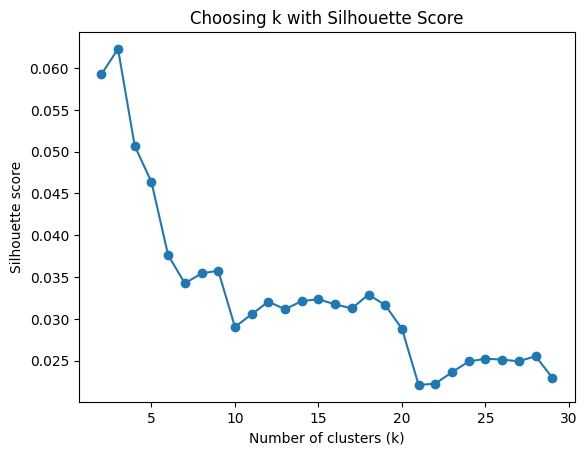

In [117]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[2 2 0 ... 2 2 2]


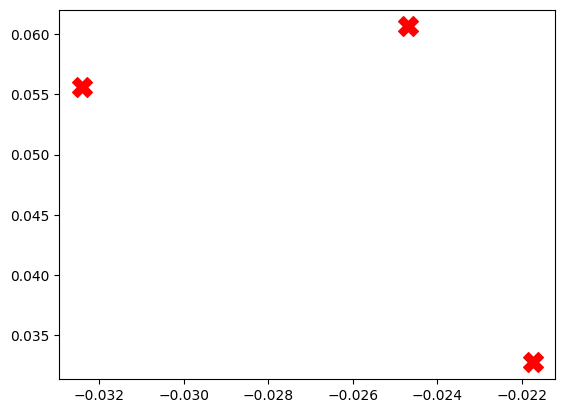

In [118]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['description_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### clustering title

In [119]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['content'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Best k: 29
Best silhouette score: 0.1903633


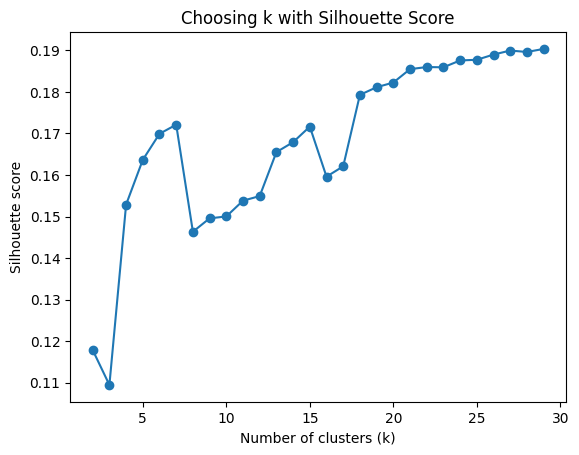

In [120]:

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[7 7 7 ... 2 2 2]


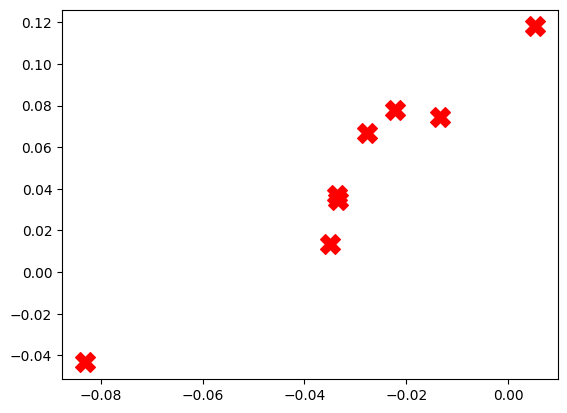

In [121]:
X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=8,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['title_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


# Vectorize video

In [21]:
# import torch
# import av
# import numpy as np

# from transformers import AutoProcessor, AutoModel


# MODEL_NAME = "microsoft/xclip-base-patch32"

# device = "cuda" if torch.cuda.is_available() else "cpu"

# processor = AutoProcessor.from_pretrained(MODEL_NAME)
# model = AutoModel.from_pretrained(MODEL_NAME).to(device)
# model.eval()


# def read_video(path, num_frames=8):
#     container = av.open(path)

#     stream = container.streams.video[0]
#     total_frames = stream.frames

#     indices = np.linspace(
#         0,
#         total_frames - 1,
#         num_frames,
#     ).astype(int)

#     frames = []

#     for i, frame in enumerate(container.decode(video=0)):
#         if i in indices:
#             frames.append(frame.to_ndarray(format="rgb24"))

#         if i > indices[-1]:
#             break

#     container.close()

#     return frames

# # num_frames uniformly sampled across video (supposedly model is optimized for 8)
# def video_embedding(path, num_frames=8):
#     video = read_video(path, num_frames)

#     inputs = processor(
#         videos=video,
#         return_tensors="pt",
#     )

#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     with torch.no_grad():
#         embedding = model.get_video_features(**inputs).pooler_output

#     embedding = torch.nn.functional.normalize(embedding, dim=-1)

#     return embedding.cpu().numpy()[0]

Loading weights:   0%|          | 0/591 [00:00<?, ?it/s]

In [22]:
# from concurrent.futures import ThreadPoolExecutor, as_completed

# MAX_WORKERS = 4

# embeddings = {}
# with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
#     futures = {
#         ex.submit(video_embedding, str(vid)): vid
#         for vid in VIDEO_DIR.glob("*.mp4")
#     }
#     for future in as_completed(futures):
#         vid = futures[future]
#         embeddings[vid.stem] = future.result()

Best k: 10
Best silhouette score: 0.07887484


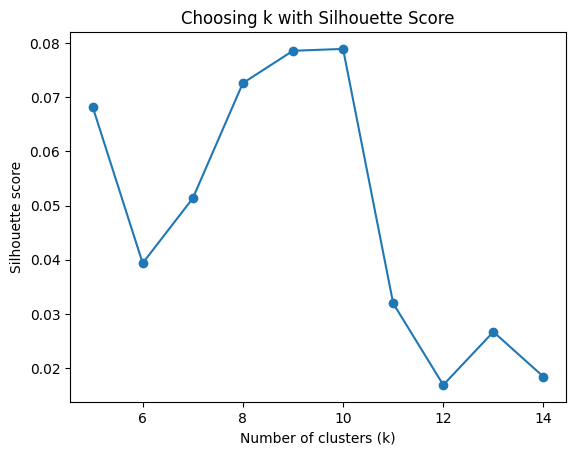

In [23]:
# X = np.array(list(embeddings.values()))

# k_range = range(5, 15)

# silhouette_scores = []

# for k in k_range:
#     clusterer = KMeans(
#         n_clusters=k,
#         random_state=42,
#         n_init="auto"
#     )
    
#     clusters = clusterer.fit_predict(X)
    
#     score = silhouette_score(X, clusters)
#     silhouette_scores.append(score)

# # Find best k
# best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

# print("Best k:", best_k)
# print("Best silhouette score:", max(silhouette_scores))

# # Plot
# plt.plot(k_range, silhouette_scores, marker="o")
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Silhouette score")
# plt.title("Choosing k with Silhouette Score")
# plt.show()

[3 2 4 0 3 3 3 3 1 0 3 1 0 0 0 2 3 3 0 4 2 3 2 3 2 0 3 3 2 0 4 0 4 4 1 3 3
 3 0 3 0 4 3 4 0 2 0 0 3 3 2 2 2 1 1 0 0 2 0 3 2 0 4 0 4 3 0 3 4 3 2 4 4 3
 3 0 3 3 3 2 3 3 3 3 0 3 0 0 2 1 3 4 0 3 3 3 2 3 2 0 0 1 0 0 4 4 3 0 3 2 0
 3 1 0 0 4 3 3 2 3 0 0 2 3 0 4 3 2 3 4 1 0 4 3 3 0 2 3 0 0 3 3 0 2 3 3 3 3
 3 3]


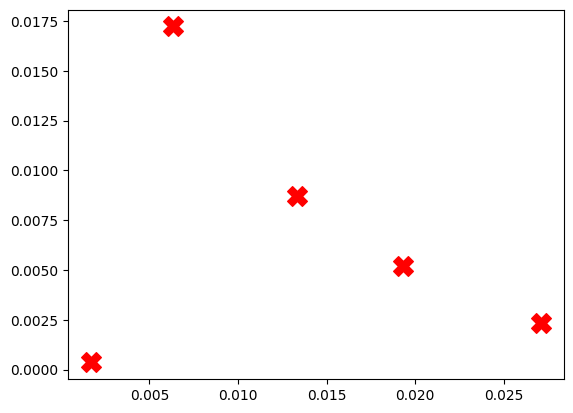

In [24]:
# X_normalized = normalize(X)

# clusterer = KMeans(
#     # n_clusters=best_k,
#     n_clusters=5,
#     random_state=42,
#     n_init="auto"
# )

# clusters = clusterer.fit_predict(X_normalized)
# print(clusters)
# described_posts['video_cluster'] = clusters

# centroids = clusterer.cluster_centers_
# plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


# feature engineering

In [122]:
from collections import Counter

import regex

POST_TITLE_COLUMN = "content"
HASHTAG_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_])#([\p{L}\p{N}_]+)")
MENTION_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_@])@([\p{L}\p{N}_][\p{L}\p{N}_.]*)")
EMOJI_PATTERN = regex.compile(
    r"(?:\p{Regional_Indicator}{2}|[#*0-9]\uFE0F?\u20E3|"
    r"\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?"
    r"(?:\u200D\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?)*)"
)


def _multi_hot_encode(frame, token_lists, prefix, column_name, min_frequency):
    if min_frequency < 1:
        raise ValueError("min_frequency must be at least 1")

    old_columns = [column for column in frame.columns if column.startswith(f"{prefix}_")]
    if old_columns:
        frame.drop(columns=old_columns, inplace=True)

    unique_tokens = token_lists.map(lambda tokens: list(dict.fromkeys(tokens)))
    frequencies = Counter(token for tokens in unique_tokens for token in tokens)
    vocabulary = sorted(token for token, count in frequencies.items() if count >= min_frequency)

    new_columns = {
        f"{prefix}_count": token_lists.map(len).astype("int16"),
        **{
            column_name(token): unique_tokens.map(
                lambda tokens, value=token: int(value in tokens)
            ).astype("int8")
            for token in vocabulary
        },
    }
    frame = pd.concat([frame, pd.DataFrame(new_columns, index=frame.index)], axis=1)
    return frame


def hashtag_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [tag.casefold() for tag in HASHTAG_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "hashtag", lambda tag: f"hashtag_{tag}", min_frequency
    )


def mention_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [mention.rstrip(".").casefold() for mention in MENTION_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "mention", lambda mention: f"mention_{mention}", min_frequency
    )


def emoji_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(EMOJI_PATTERN.findall)

    def emoji_column(value):
        codepoints = "_".join(f"{ord(char):x}" for char in value)
        return f"emoji_u{codepoints}"

    return _multi_hot_encode(frame, tokens, "emoji", emoji_column, min_frequency)


df = hashtag_encode(df)
df = mention_encode(df)
df = emoji_encode(df)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,emoji_u1fae3,emoji_u1fae8,emoji_u1faf0_1f3fd,emoji_u1faf3,emoji_u1faf3_1f3fd,emoji_u1faf5_1f3fc,emoji_u1faf5_1f3fd,emoji_u1faf6,emoji_u1faf6_1f3fc,emoji_u1faf6_1f3fd
9460,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75008323...,Missing Post Content,...,0,0,0,0,0,0,0,0,0,0
9461,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75026195...,Missing Post Content,...,0,0,0,0,0,0,0,0,0,0
9462,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75089302...,Missing Post Content,...,0,0,0,0,0,0,0,0,0,0
9467,Organic | Website,2025,NZR,TT,Short Video,Social,Teams Promo,NZU20s,https://www.tiktok.com/@nzrugby/video/74957010...,#nzu20s,...,0,0,0,0,0,0,0,0,0,0
9471,Organic | Website,2025,NZR,TT,Short Video,Social,Teams Promo,NZU20s,https://www.tiktok.com/@nzrugby/video/75012686...,"@mosese bason will captain the nz u20s today, ...",...,0,0,0,0,0,0,0,0,0,0


In [123]:
CATEGORICAL_COLUMNS = [
    "category_l0",
    "category_l1",
    "category_l2",
    "page",
    "platform",
]
CATEGORY_FIXED = "Missing Category"

for column in CATEGORICAL_COLUMNS:
    cleaned = df[column].fillna(CATEGORY_FIXED).astype(str).str.strip()
    cleaned = cleaned.replace({"": CATEGORY_FIXED})
    frame = pd.get_dummies(cleaned, prefix=f"cat_{column}")
    df = pd.concat([df, frame.astype("int8")], axis=1)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,cat_category_l2_Triple Threat,cat_category_l2_U85s,cat_category_l2_WIP,cat_category_l2_WRWC 2025,cat_page_All Blacks,cat_page_Black Ferns,cat_page_NZ Sevens,cat_page_NZR,cat_platform_TT,cat_platform_YT
9460,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75008323...,Missing Post Content,...,0,0,0,0,0,0,0,1,1,0
9461,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75026195...,Missing Post Content,...,0,0,0,0,0,0,0,1,1,0
9462,Organic | Website,2025,NZR,TT,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.tiktok.com/@nzrugby/video/75089302...,Missing Post Content,...,0,0,0,0,0,0,0,1,1,0
9467,Organic | Website,2025,NZR,TT,Short Video,Social,Teams Promo,NZU20s,https://www.tiktok.com/@nzrugby/video/74957010...,#nzu20s,...,0,0,0,0,0,0,0,1,1,0
9471,Organic | Website,2025,NZR,TT,Short Video,Social,Teams Promo,NZU20s,https://www.tiktok.com/@nzrugby/video/75012686...,"@mosese bason will captain the nz u20s today, ...",...,0,0,0,0,0,0,0,1,1,0


0


<Axes: >

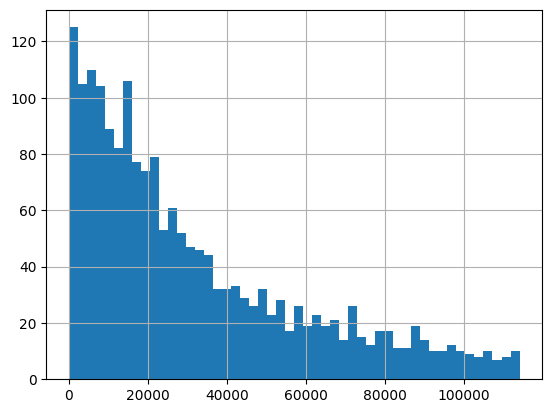

In [126]:
print(df['views'].isna().sum())


Q1 = df['views'].quantile(0.25)
Q3 = df['views'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['views'] >= lower_bound) & (df['views'] <= upper_bound)]
# df.boxplot(column='views')
df['views'].hist(bins=50)

0


<Axes: >

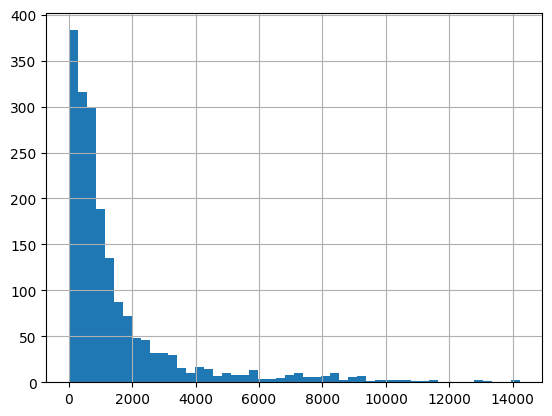

In [127]:

print(df['engagement'].isna().sum())

df = df[(df['engagement'] >= lower_bound) & (df['engagement'] <= upper_bound)]

# df.boxplot(column='views')
df['engagement'].hist(bins=50)

In [128]:
# pd.set_option('display.max_columns', None)
# len(len(df.columns.tolist()))
print(df.columns.tolist()) 

['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0', 'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views', 'hours', 'engagement', 'description', 'json_content_theme_celebration', 'json_content_theme_challenges', 'json_content_theme_conversion', 'json_content_theme_haka', 'json_content_theme_kick', 'json_content_theme_non rugby related', 'json_content_theme_player story', 'json_content_theme_rivalry', 'json_content_theme_rugby_skills', 'json_content_theme_run', 'json_content_theme_tackle', 'json_content_theme_training', 'json_content_theme_try', 'json_content_theme_undefined', 'json_format_access_announcement', 'json_format_access_archive', 'json_format_access_behind-the-scenes', 'json_format_access_candid clip', 'json_format_access_highlight', 'json_format_access_interview', 'json_format_access_montage', 'json_format_access_promotion', 'json_format_access_reaction', 'json_format_access_ticket sales', 'json_format_access_undefined', 'json_people_aaron cru

## linreg views

In [129]:
DROP_COLS = ['campaign', 'year', 'page', 'platform', \
             'media_type', 'category_l0', 'category_l1', 'category_l2', \
             'url', 'content', 'cost_nzd', 'views', \
             'hours', 'engagement', 'description']

X = df.drop(columns=DROP_COLS)
y = np.log1p(df['views'])


In [130]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

1491 373
1491 373


Mean Squared Error (MSE): 74.9265
R-squared (R2) Score: -20.7505


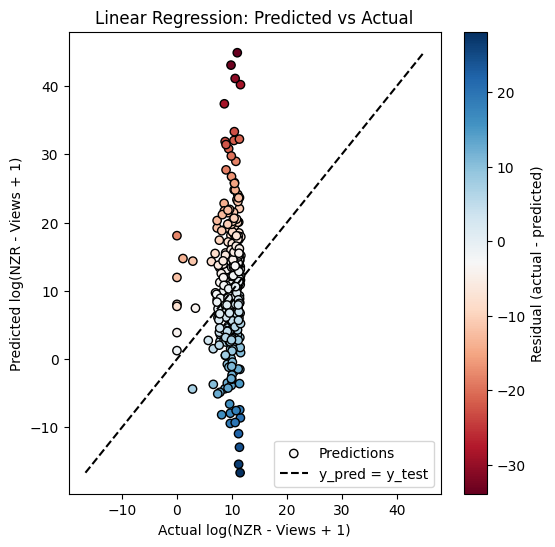

In [131]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 7. Plot predicted vs actual with a y=x reference line.
y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Views + 1)')
plt.ylabel('Predicted log(NZR - Views + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [132]:
# predicted views diff vs actual
# diff = abs(round(np.expm1(y_pred) -  np.expm1(y_test)))
# sorted(diff)

In [133]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])


top 5 negative:
-28.1286017029309 json_brands_castle lager
-24.136506130206755 hashtag_wellington
-24.06158783036087 hashtag_workout
-22.702124926615323 hashtag_thunderstruck
-20.40330802003393 json_people_pellegrini
top 5 positive:
31.036135718273282 json_people_springboks rugby team
26.331801186712248 json_people_victor matfield
25.529356336984694 json_brands_cbre
24.689099875517467 json_brands_energade
23.834068821479516 hashtag_rugbytraining


## linreg engagement

In [134]:
X = df.drop(columns=DROP_COLS)

y = np.log1p(df['engagement'])

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

1491 373
1491 373


Mean Squared Error (MSE): 168.8081
R-squared (R2) Score: -71.9525


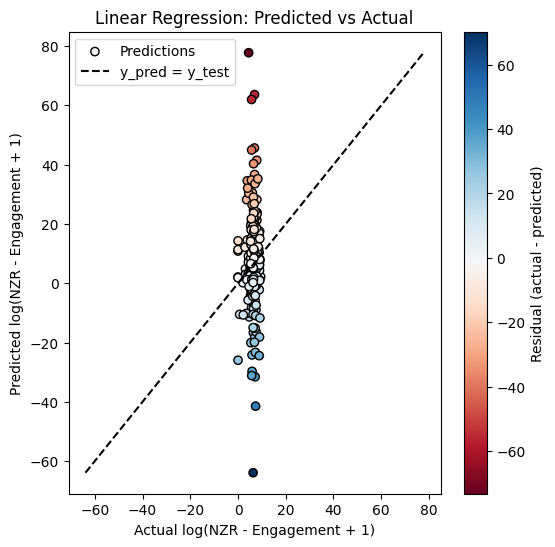

In [136]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Engagement + 1)')
plt.ylabel('Predicted log(NZR - Engagement + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [137]:
# diff = abs(round(np.expm1(y_pred) - np.expm1(y_test)))
# sorted(diff)

In [138]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])

top 5 negative:
-47.4408507670049 json_people_risaleaana pouri-lane
-45.42662341275337 json_people_andrew ellis
-44.590374829447526 mention_shiray_k9
-38.331500824977574 json_people_pellegrini
-33.14157404522317 json_people_tupou va'ai
top 5 positive:
80.21553438490878 json_brands_rode
65.71157402227061 hashtag_goldmedal
33.64058285701358 json_people_ben may
33.55147082474616 json_people_georgia miller
32.29095611763622 json_people_shiray kaka


## linreg views + engagement (multivariate)

In [140]:
X = df.drop(columns=DROP_COLS)

y = np.log1p(df[['views', 'engagement']])

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

1491 373
1491 373


views - Mean Squared Error (MSE): 68.8707
views - R-squared (R2) Score: -22.5641
engagement - Mean Squared Error (MSE): 51.8167
engagement - R-squared (R2) Score: -21.1548


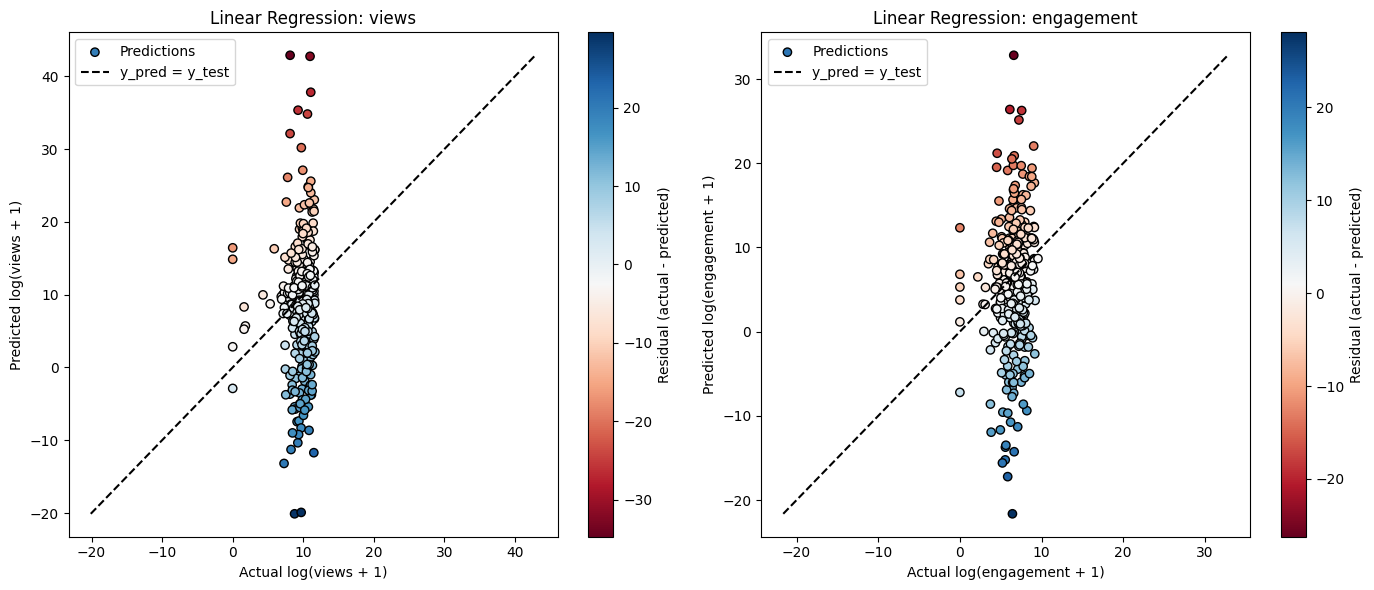

In [143]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

targets = ['views', 'engagement']
for i, name in enumerate(targets):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"{name} - Mean Squared Error (MSE): {mse:.4f}")
    print(f"{name} - R-squared (R2) Score: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (ax, name) in enumerate(zip(axes, targets)):
    y_test_array = np.asarray(y_test.iloc[:, i]).ravel()
    y_pred_array = np.asarray(y_pred[:, i]).ravel()
    residuals = y_test_array - y_pred_array
    ref_min = float(min(y_test_array.min(), y_pred_array.min()))
    ref_max = float(max(y_test_array.max(), y_pred_array.max()))
    scatter = ax.scatter(
        y_test_array, y_pred_array, c=residuals, cmap='RdBu',
        edgecolor='k', label='Predictions',
    )
    ax.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
    ax.set_xlabel(f'Actual log({name} + 1)')
    ax.set_ylabel(f'Predicted log({name} + 1)')
    ax.set_title(f'Linear Regression: {name}')
    fig.colorbar(scatter, ax=ax, label='Residual (actual - predicted)')
    ax.legend()
plt.tight_layout()
plt.show()

In [42]:
for i, name in enumerate(targets):
    diff = abs(round(np.expm1(y_pred[:, i]) - np.expm1(y_test.iloc[:, i])))
    print(name)
    print(sorted(diff))

NZR - Views
[66.0, 2144.0, 2791.0, 10023.0, 27555.0, 33070.0, 38902.0, 41160.0, 55226.0, 57251.0, 61328.0, 73248.0, 78427.0, 90870.0, 91065.0, 119543.0, 120666.0, 128581.0, 133857.0, 192303.0, 250022.0, 257931.0, 355317.0, 360000.0, 573152.0, 938685.0, 2899654.0, 4344930.0, 5023060.0, 7917493.0]
NZR - Engagement
[3.0, 36.0, 36.0, 55.0, 118.0, 572.0, 960.0, 1118.0, 1278.0, 1321.0, 1539.0, 1581.0, 1780.0, 2388.0, 3418.0, 4276.0, 4794.0, 4920.0, 5279.0, 5460.0, 6259.0, 7231.0, 10866.0, 11838.0, 12483.0, 15981.0, 107250.0, 121983.0, 385417.0, 387498.0]


In [43]:
for i, name in enumerate(targets):
    important_features = sorted(zip(model.coef_[i], X_train.columns))

    print(f'top 5 negative ({name}):')
    for t in important_features[:5]:
        print(t[0], t[1])

    print(f'top 5 positive ({name}):')
    for t in reversed(important_features[-5:]):
        print(t[0], t[1])

top 5 negative (NZR - Views):
-3.3859118672052038 emoji_u1f62e_200d_1f4a8
-2.81383653683669 hashtag_chicago
-2.5728379888882476 hashtag_wellington
-2.5274574877203477 emoji_u1f381
-2.217787531783899 emoji_u1f512
top 5 positive (NZR - Views):
6.379990038746026 hashtag_rugby
3.512049604356811 hashtag_blackfernssevens
3.0420810467205364 hashtag_nz
2.995990742752318 hashtag_hk7s
2.802169780685565 hashtag_football
top 5 negative (NZR - Engagement):
-4.261081167441169 hashtag_chicago
-4.005554550864094 emoji_u1f62e_200d_1f4a8
-3.9875802237539295 hashtag_wellington
-3.529972972384898 hashtag_haka
-3.445594249988581 hashtag_sports
top 5 positive (NZR - Engagement):
4.9403225003654585 emoji_u27a1_fe0f
4.704841098466701 hashtag_rugby
3.883097834834119 emoji_u1f4f2
3.1875334006684 hashtag_hk7s
3.0794261538896364 cat_NZR - Platform Code_IG


<Axes: xlabel='engagement', ylabel='views'>

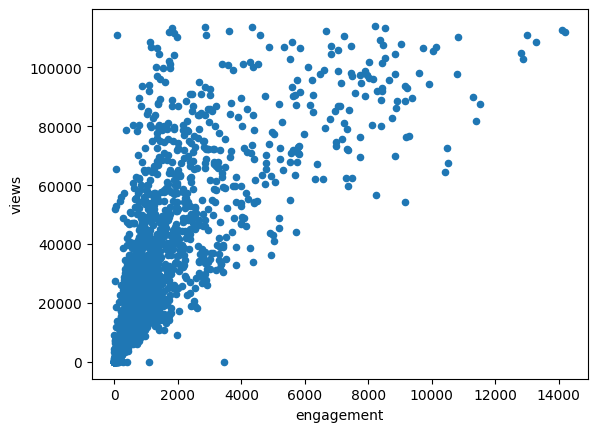

In [146]:
df.plot.scatter(x='engagement', y='views')